# Cost Function — Linear Regression with One Variable

**Goal:** Visualize and understand $J(w,b)$, the function that measures how
well a given $(w, b)$ fits the training data.

$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

We're continuing with the same years-of-experience vs. salary dataset from
the previous topic. In that lab we picked `(w, b)` by hand and eyeballed
which fit looked best. Here we make that comparison rigorous, by computing
an actual number for every choice of `(w, b)` -- and visualizing the shape
of that "cost landscape." Next topic (Gradient Descent) will use this same
landscape to *automatically* walk downhill to the minimum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from cost_function import compute_cost, compute_cost_grid, grid_search_minimum

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('data.csv')
x_train = df['years_experience'].values
y_train = df['salary_in_1000s'].values
m = x_train.shape[0]
print(f"m = {m} training examples")

m = 30 training examples


## 1. Cost vs. w (holding b fixed)

If we freeze `b` at a reasonable value and only vary `w`, what does the
cost look like? This is a 1D slice through the cost function.

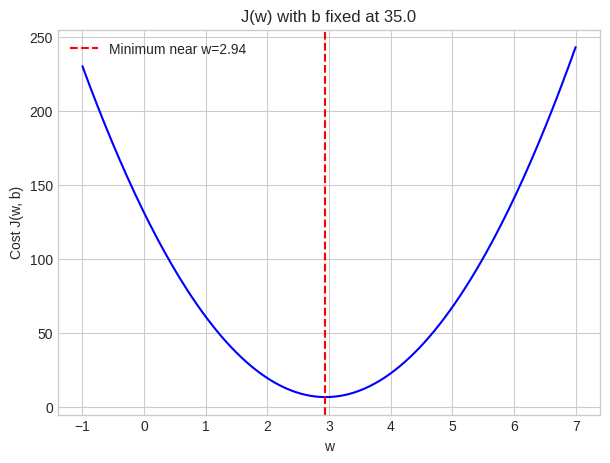

Lowest cost in this slice: 6.772 at w=2.94


In [2]:
b_fixed = 35.0
w_values = np.linspace(-1, 7, 200)
costs = [compute_cost(x_train, y_train, w, b_fixed) for w in w_values]

best_w_1d = w_values[np.argmin(costs)]

plt.figure(figsize=(7, 5))
plt.plot(w_values, costs, c='blue')
plt.axvline(best_w_1d, color='red', linestyle='--',
            label=f'Minimum near w={best_w_1d:.2f}')
plt.title(f"J(w) with b fixed at {b_fixed}")
plt.xlabel("w")
plt.ylabel("Cost J(w, b)")
plt.legend()
plt.savefig('cost_vs_w.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Lowest cost in this slice: {min(costs):.3f} at w={best_w_1d:.2f}")

Notice the shape: a smooth bowl (parabola). This convex shape is exactly
what makes gradient descent reliable for linear regression -- there's a
single minimum to walk downhill toward, no risk of getting stuck in a
local dip.

## 2. Cost surface over both w AND b (contour plot)

Grid search minimum: w=3.20, b=33.23, cost=6.335
(Recall: this synthetic data was generated with true w=3.0, b=35.0 -- close!)


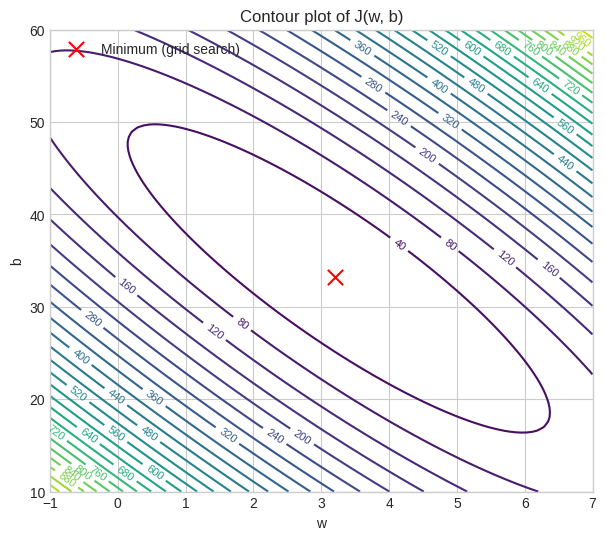

In [3]:
w_range = np.linspace(-1, 7, 100)
b_range = np.linspace(10, 60, 100)
W, B, J = compute_cost_grid(x_train, y_train, w_range, b_range)

best_w, best_b, best_cost = grid_search_minimum(x_train, y_train, w_range, b_range)
print(f"Grid search minimum: w={best_w:.2f}, b={best_b:.2f}, cost={best_cost:.3f}")
print("(Recall: this synthetic data was generated with true w=3.0, b=35.0 -- close!)")

plt.figure(figsize=(7, 6))
cp = plt.contour(W, B, J, levels=30, cmap='viridis')
plt.clabel(cp, inline=True, fontsize=8)
plt.scatter([best_w], [best_b], c='red', marker='x', s=120, label='Minimum (grid search)')
plt.title("Contour plot of J(w, b)")
plt.xlabel("w")
plt.ylabel("b")
plt.legend()
plt.savefig('cost_contour.png', dpi=120, bbox_inches='tight')
plt.show()

Each contour line is a set of `(w, b)` pairs with *equal* cost -- like
elevation lines on a topographic map. The center of the rings is the
minimum: the best possible `(w, b)` for this data.

## 3. The same thing in 3D (the classic "soup bowl")

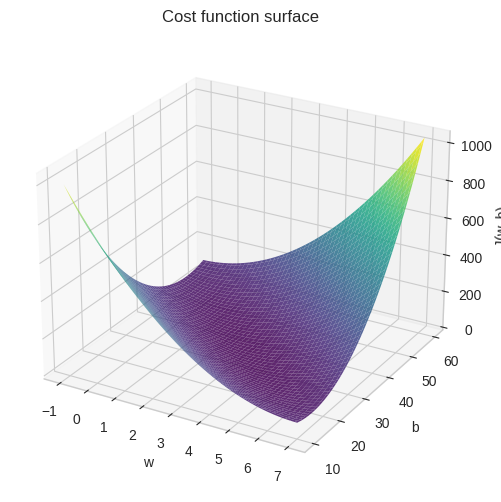

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J, cmap='viridis', alpha=0.85)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('J(w, b)')
ax.set_title('Cost function surface')
ax.view_init(elev=25, azim=-60)
plt.savefig('cost_surface.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Interactive: line fit + cost location, side by side (optional — run in Jupyter/Colab)

Drag the sliders and watch both panels update together: the left panel
shows the actual line against the data, the right panel shows *where that
choice sits* on the cost contour map. Dragging toward the center of the
rings should also produce a visually tighter line fit on the left.

In [5]:
from ipywidgets import interact, FloatSlider

def plot_side_by_side(w=3.0, b=35.0):
    cost = compute_cost(x_train, y_train, w, b)
    f_wb = w * x_train + b

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(x_train, y_train, marker='x', c='red', label='Actual data')
    axes[0].plot(x_train, f_wb, c='blue', label=f'f(x) = {w:.1f}x + {b:.1f}')
    axes[0].set_title(f"Line fit  |  Cost = {cost:.2f}")
    axes[0].set_xlabel("Years of Experience")
    axes[0].set_ylabel("Salary (in $1000s)")
    axes[0].set_ylim(20, 70)
    axes[0].legend()

    cp = axes[1].contour(W, B, J, levels=30, cmap='viridis')
    axes[1].scatter([w], [b], c='red', marker='x', s=150, zorder=5)
    axes[1].set_title("Position on cost contour")
    axes[1].set_xlabel("w")
    axes[1].set_ylabel("b")

    plt.tight_layout()
    plt.show()

interact(plot_side_by_side,
         w=FloatSlider(min=-1, max=7, step=0.1, value=3.0),
         b=FloatSlider(min=10, max=60, step=1, value=35.0));

interactive(children=(FloatSlider(value=3.0, description='w', max=7.0, min=-1.0), FloatSlider(value=35.0, desc…

## Takeaways

- $J(w,b)$ turns "how good is this fit?" into a single comparable number.
- For linear regression, the cost surface is a smooth, convex bowl --
  exactly one minimum, no local dips to get trapped in.
- We found the approximate minimum here with brute-force grid search,
  which doesn't scale (imagine doing this with 10+ parameters). **Next
  up: Gradient Descent** — an algorithm that walks downhill on this
  exact surface automatically, using calculus instead of guesswork.